In [1]:
# Code for environment setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")


Libraries imported successfully!


In [3]:
df = pd.read_csv('Manchester_house_Dataset[3678].csv')
print("Dataset Shape:", df.shape)
print("\nDataset Info:")
df.info()
print("\nFirst 5 rows:")
df.head()


Dataset Shape: (19999, 15)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19999 entries, 0 to 19998
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   19999 non-null  int64  
 1   id           19999 non-null  int64  
 2   price        19999 non-null  int64  
 3   bedrooms     19986 non-null  float64
 4   bathrooms    19989 non-null  float64
 5   sqft_living  19999 non-null  int64  
 6   sqft_total   19999 non-null  int64  
 7   floors       19999 non-null  float64
 8   waterfront   19999 non-null  int64  
 9   view         19999 non-null  int64  
 10  condition    19999 non-null  int64  
 11  grade        19999 non-null  int64  
 12  built        19999 non-null  int64  
 13  renovated    19999 non-null  int64  
 14  living_area  19999 non-null  int64  
dtypes: float64(3), int64(12)
memory usage: 2.3 MB

First 5 rows:


,Unnamed: 0,id,price,bedrooms,bathrooms,sqft_living,sqft_total,floors,waterfront,view,condition,grade,built,renovated,living_area
0,0,7129300520,221900,3.0,1.00,1180,5650,1.0,0,0,3,7,1955,0,1340
1,1,6414100192,538000,3.0,2.25,2570,7242,2.0,0,0,3,7,1951,1991,1690
2,2,5631500400,180000,2.0,1.00,770,10000,1.0,0,0,3,6,1933,0,2720
3,3,2487200875,604000,4.0,3.00,1960,5000,1.0,0,0,5,7,1965,0,1360
4,4,1954400510,510000,3.0,2.00,1680,8080,1.0,0,0,3,8,1987,0,1800


In [4]:
# Code for removing non-predictive columns
print("Columns before removal:", df.columns.tolist())
df_clean = df.drop(['id', 'Unnamed: 0'], axis=1)
print("Columns after removal:", df_clean.columns.tolist())


Columns before removal: ['Unnamed: 0', 'id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_total', 'floors', 'waterfront', 'view', 'condition', 'grade', 'built', 'renovated', 'living_area']
Columns after removal: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_total', 'floors', 'waterfront', 'view', 'condition', 'grade', 'built', 'renovated', 'living_area']


In [5]:
# Code for median imputation
print("Missing values before imputation:")
print(df_clean[['bedrooms', 'bathrooms']].isnull().sum())

bedrooms_median = df_clean['bedrooms'].median()
bathrooms_median = df_clean['bathrooms'].median()

df_clean['bedrooms'].fillna(bedrooms_median, inplace=True)
df_clean['bathrooms'].fillna(bathrooms_median, inplace=True)

print("\nMissing values after imputation:")
print(df_clean[['bedrooms', 'bathrooms']].isnull().sum())


Missing values before imputation:
bedrooms     13
bathrooms    10
dtype: int64

Missing values after imputation:
bedrooms     0
bathrooms    0
dtype: int64


In [6]:
# Code for outlier filtering
print(f"Rows before filtering: {len(df_clean)}")
print(f"Properties with bedrooms > 10: {(df_clean['bedrooms'] > 10).sum()}")

df_clean = df_clean[df_clean['bedrooms'] <= 10]
print(f"Rows after filtering: {len(df_clean)}")


Rows before filtering: 19999
Properties with bedrooms > 10: 2
Rows after filtering: 19997


In [7]:
# Code to verify cleaned data
print("Final dataset shape:", df_clean.shape)
print("\nTotal null values:", df_clean.isnull().sum().sum())
print("\nBasic statistics:")
df_clean.describe()


Final dataset shape: (19997, 13)

Total null values: 0

Basic statistics:


,price,bedrooms,bathrooms,sqft_living,sqft_total,floors,waterfront,view,condition,grade,built,renovated,living_area
count,1.999700e+04,19997.000000,19997.000000,19997.000000,1.999700e+04,19997.000000,19997.000000,19997.000000,19997.000000,19997.000000,19997.000000,19997.000000,19997.000000
mean,5.354636e+05,3.364505,2.072911,2057.862679,1.560801e+04,1.444867,0.007951,0.241786,3.441716,7.605791,1967.958194,90.721158,1974.352503
std,3.659742e+05,0.904362,0.760962,905.659532,4.177316e+04,0.516674,0.088816,0.777958,0.665398,1.172667,28.316317,415.749257,675.265445
min,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,1900.000000,0.000000,399.000000
25%,3.170000e+05,3.000000,1.500000,1420.000000,5.350000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1950.000000,0.000000,1490.000000
50%,4.499000e+05,3.000000,2.000000,1900.000000,7.819000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1969.000000,0.000000,1830.000000
75%,6.400000e+05,4.000000,2.500000,2510.000000,1.100000e+04,2.000000,0.000000,0.000000,4.000000,8.000000,1991.000000,0.000000,2340.000000
max,7.700000e+06,10.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,2015.000000,2015.000000,6210.000000


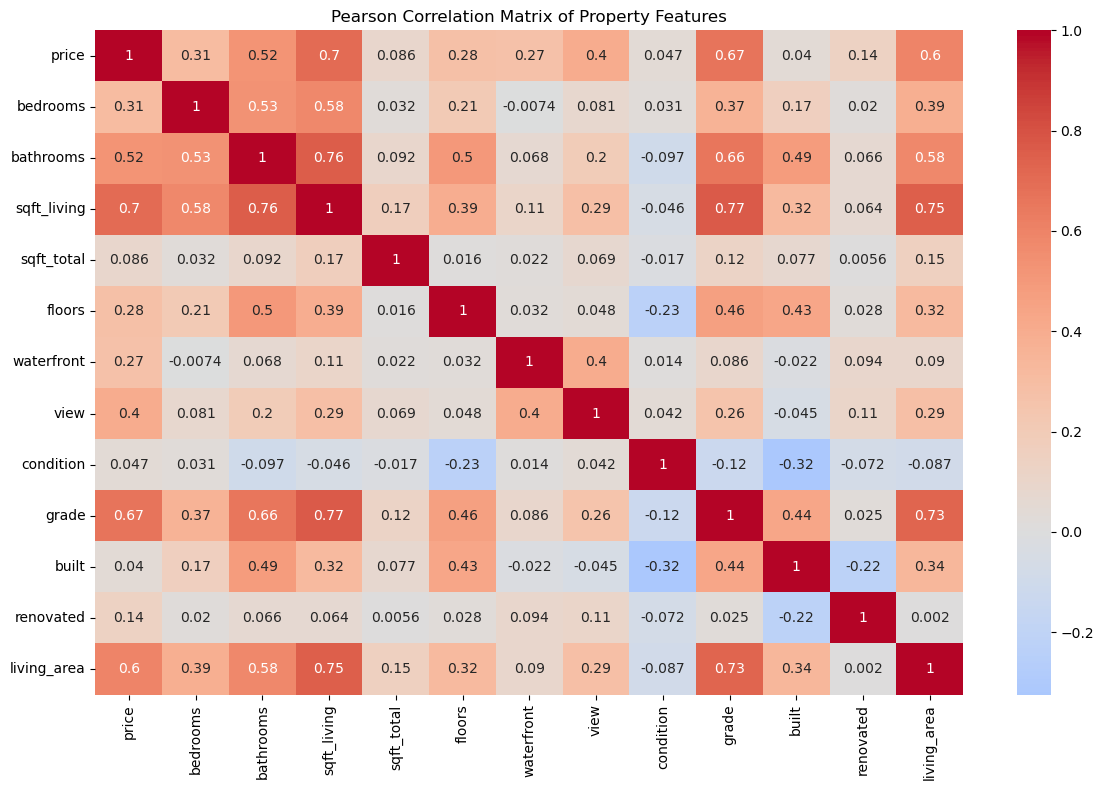

In [8]:
# Code for correlation matrix
correlation_matrix = df_clean.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Pearson Correlation Matrix of Property Features')
plt.tight_layout()
plt.savefig('correlation_matrix.png',dpi=2000)
plt.show()


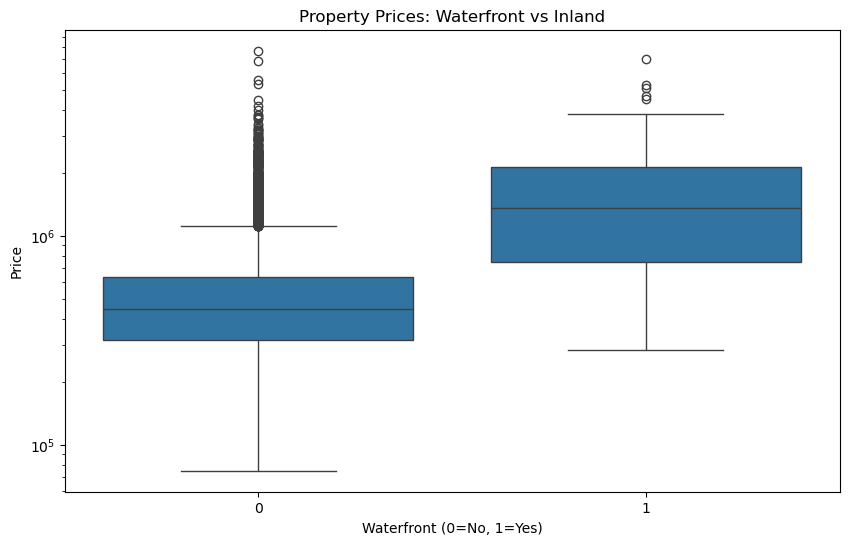

In [9]:
# Code for waterfront vs inland comparison
plt.figure(figsize=(10, 6))
sns.boxplot(x='waterfront', y='price', data=df_clean)
plt.title('Property Prices: Waterfront vs Inland')
plt.xlabel('Waterfront (0=No, 1=Yes)')
plt.ylabel('Price')
plt.yscale('log')
plt.savefig('waterfront_vs_inland.png',dpi=1000)
plt.show()


In [10]:
# Code for detailed waterfront analysis
waterfront_stats = df_clean.groupby('waterfront')['price'].describe()
print("Waterfront Property Statistics:")
print(waterfront_stats)
waterfront_median = df_clean[df_clean['waterfront']==1]['price'].median()
inland_median = df_clean[df_clean['waterfront']==0]['price'].median()
premium_percentage = ((waterfront_median - inland_median) / inland_median) * 100

print(f"\nWaterfront premium: {premium_percentage:.2f}%")


Waterfront Property Statistics:
              count          mean           std       min       25%  \
waterfront                                                            
0           19838.0  5.266598e+05  3.395993e+05   75000.0  315462.5   
1             159.0  1.633892e+06  1.116825e+06  285000.0  750000.0   

                  50%        75%        max  
waterfront                                   
0            446350.0   635000.0  7700000.0  
1           1365000.0  2137500.0  7062500.0  

Waterfront premium: 205.81%


In [11]:
# Code for floor space vs price analysis
correlation = df_clean['sqft_living'].corr(df_clean['price'])
print(f"Pearson correlation coefficient: {correlation:.3f}")


Pearson correlation coefficient: 0.701


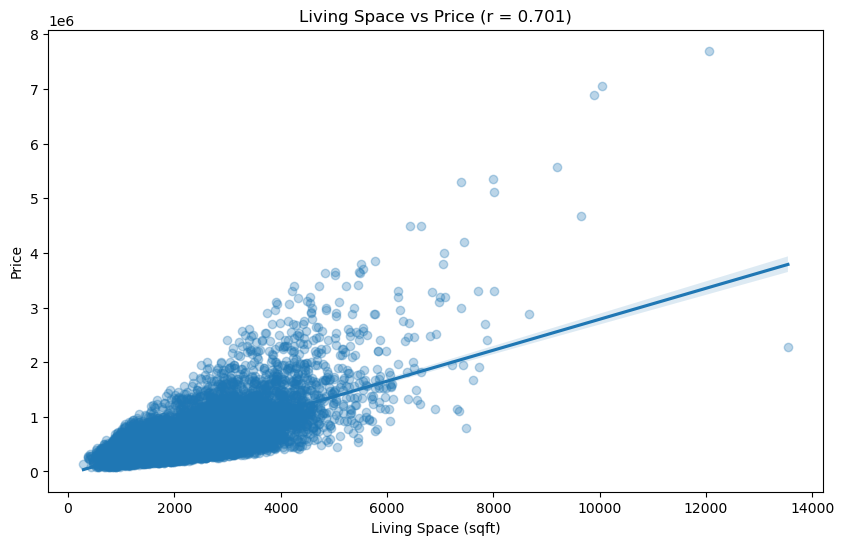

In [12]:
# Code for scatter plot with regression line
plt.figure(figsize=(10, 6))
sns.regplot(x='sqft_living', y='price', data=df_clean, scatter_kws={'alpha':0.3})
plt.title(f'Living Space vs Price (r = {correlation:.3f})')
plt.xlabel('Living Space (sqft)')
plt.ylabel('Price')
plt.savefig('living_space_vs_price.png',dpi=1000)
plt.show()
